# CORAL vs coGOL: Understanding Ordinal Regression Losses

**Goal:** Build deep intuition for two ordinal regression losses by implementing them from scratch on a 2D synthetic dataset, then visualizing everything.

**Papers:**
- **CORAL** — Cao, Mirjalili & Raschka (2019): *"Rank consistent ordinal regression for neural networks"* ([arxiv:1901.07884](https://arxiv.org/abs/1901.07884))
- **coGOL** — Lu, Ferraro & Raff (2022): *"Continuously Generalized Ordinal Regression for Linear and Deep Models"* ([arxiv:2202.07005](https://arxiv.org/abs/2202.07005))

**Why this matters for our project:** Both losses are candidates for the Novozymes enzyme stability prediction task, where we discretize the continuous `tm` target into ordinal bins. Understanding *when* CORAL's parallel-hyperplane assumption breaks down — and how coGOL fixes it — is critical for choosing the right loss.

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D

torch.manual_seed(42)
np.random.seed(42)

# Constants
K = 6          # number of ordinal classes (1, 2, ..., 6)
N_THRESHOLDS = K - 1  # 5 binary tasks
DEVICE = "cpu"

print(f"Ordinal classes: K={K}, Binary threshold tasks: {N_THRESHOLDS}")

Ordinal classes: K=6, Binary threshold tasks: 5


---
## 1. Mathematical Foundations

### 1a. The Ordinal Regression Setup

Given $K$ ordered classes $1 \prec 2 \prec \ldots \prec K$, ordinal regression transforms the problem into $K-1$ **binary threshold tasks**.

For a sample with true class $y_i$, we create **extended binary labels**:

$$\tilde{y}_i^{(j)} = \mathbb{1}\{y_i > j\} \quad \text{for } j = 1, 2, \ldots, K-1$$

**Example** with $K=6$: A sample with true class $y=4$ gets binary labels:

| Threshold $j$ | Question: "$y > j$?" | Binary label $\tilde{y}^{(j)}$ |
|:-:|:-:|:-:|
| 1 | $4 > 1$? Yes | 1 |
| 2 | $4 > 2$? Yes | 1 |
| 3 | $4 > 3$? Yes | 1 |
| 4 | $4 > 4$? No | 0 |
| 5 | $4 > 5$? No | 0 |

So class 4 is encoded as $[1, 1, 1, 0, 0]$. Note that binary labels are **always monotonically non-increasing** by construction — once a 0 appears, all subsequent entries must also be 0.

In [2]:
# Demonstrate binary label encoding
def encode_ordinal_labels(y: torch.Tensor, k: int) -> torch.Tensor:
    """Convert class labels y (1-indexed) to extended binary labels.
    
    y: [N] integer tensor with values in {1, 2, ..., K}
    Returns: [N, K-1] binary tensor where entry (i, j) = 1 if y_i > j+1
    """
    # j ranges from 1 to K-1 (thresholds)
    thresholds = torch.arange(1, k, dtype=y.dtype, device=y.device)  # [K-1]
    return (y.unsqueeze(1) > thresholds.unsqueeze(0)).float()  # [N, K-1]

# Show example
example_classes = torch.tensor([1, 2, 3, 4, 5, 6])
example_binary = encode_ordinal_labels(example_classes, K)

print("Class -> Extended binary labels (K-1 = 5 columns)")
print("-" * 50)
for cls, binary in zip(example_classes, example_binary):
    print(f"  Class {cls.item()}: {binary.int().tolist()}")

Class -> Extended binary labels (K-1 = 5 columns)
--------------------------------------------------
  Class 1: [0, 0, 0, 0, 0]
  Class 2: [1, 0, 0, 0, 0]
  Class 3: [1, 1, 0, 0, 0]
  Class 4: [1, 1, 1, 0, 0]
  Class 5: [1, 1, 1, 1, 0]
  Class 6: [1, 1, 1, 1, 1]


### 1b. CORAL Loss (Cao et al., 2019)

**Architecture:** A single shared weight vector $\mathbf{w} \in \mathbb{R}^p$ and $K-1$ independent bias terms $b_1, b_2, \ldots, b_{K-1}$.

For each threshold task $k$, the logit is:

$$h_k(\mathbf{x}) = \mathbf{w}^T \mathbf{x} + b_k$$

All $K-1$ classifiers share the **same** $\mathbf{w}$ — they only differ in bias $b_k$. In 2D, this means all decision boundaries are **parallel lines** (same slope from $\mathbf{w}$, different intercepts from $b_k$).

**Loss function** (paper Eq. 4 — binary cross-entropy summed over all thresholds):

$$\mathcal{L}_{\text{CORAL}} = -\sum_{i=1}^{N} \sum_{k=1}^{K-1} \left[ \tilde{y}_i^{(k)} \log \sigma(h_k(\mathbf{x}_i)) + (1 - \tilde{y}_i^{(k)}) \log(1 - \sigma(h_k(\mathbf{x}_i))) \right]$$

where $\sigma(z) = \frac{1}{1 + e^{-z}}$ is the sigmoid function.

**Rank consistency guarantee (Theorem 1):** Because all classifiers share $\mathbf{w}$, the optimal biases satisfy $b_1^* \geq b_2^* \geq \ldots \geq b_{K-1}^*$, which guarantees:

$$\hat{P}(y > 1) \geq \hat{P}(y > 2) \geq \ldots \geq \hat{P}(y > K-1)$$

**No rank inconsistencies are possible.** This is CORAL's key theoretical contribution.

**Inference:** Convert probabilities back to a class prediction:

$$\hat{y} = 1 + \sum_{k=1}^{K-1} \mathbb{1}\{\sigma(h_k(\mathbf{x})) > 0.5\}$$

**Limitation:** The parallel hyperplane constraint is too rigid when the true decision boundaries have different slopes.

### 1c. coGOL Loss (Lu, Ferraro & Raff, 2022)

**Key insight:** CORAL forces all decision boundaries to be parallel. Real data often has boundaries with **different slopes**. coGOL relaxes this by giving each threshold its own weight vector, then **regularizing** how much they can differ.

**Architecture:** $K-1$ independent weight vectors $\mathbf{w}_j \in \mathbb{R}^p$ and $K-1$ biases $\theta_j$.

For each threshold task $j$, the decision function is:

$$\tilde{g}_j(\mathbf{x}) = \theta_j - \mathbf{w}_j^T \mathbf{x}$$

Note the sign convention: $\tilde{g}_j(\mathbf{x}) > 0$ means class $\leq j$, and $\tilde{g}_j(\mathbf{x}) < 0$ means class $> j$.

**Decomposition:** Each weight vector is split into a pooled (shared) estimate plus a per-class deviation:

$$\mathbf{w}_j = \bar{\mathbf{w}} + \boldsymbol{\delta}_j$$

where $\bar{\mathbf{w}}$ is the mean weight vector and $\boldsymbol{\delta}_j = \mathbf{w}_j - \mathbf{w}_{j-1}$ measures how much neighboring boundaries differ.

**All-thresholds loss** (paper Eq. 3.3):

$$\mathcal{L}_{\text{coGOL}} = \underbrace{\sum_{j=1}^{y-1} \phi(-\tilde{g}_j(\mathbf{x})) + \sum_{j=y}^{K-1} \phi(\tilde{g}_j(\mathbf{x}))}_{\text{data loss: all thresholds contribute}} + \underbrace{\alpha \sum_{j=1}^{K-1} \|\mathbf{w}_j\|_2^2}_{\text{L2 weight decay}} + \underbrace{\beta \sum_{j=2}^{K-1} \|\boldsymbol{\delta}_j\|_2^2}_{\text{deviation penalty}}$$

where $\phi(z) = \log(1 + e^{-z})$ is the logistic surrogate loss.

**The $\beta$ parameter controls everything:**

| $\beta$ | Effect | Equivalent to |
|:---:|:---|:---|
| $\beta \to \infty$ | Forces $\boldsymbol{\delta}_j \to 0$ (all weights equal) | **CORAL** (parallel hyperplanes) |
| $\beta = 0$ | No constraint on weights | **GOL / OR-CNN** (fully independent) |
| $0 < \beta < \infty$ | Smooth interpolation | **coGOL** (neighboring-class smoothness) |

**Why "all-thresholds" matters:** The loss penalizes **every** threshold for every sample, not just the two thresholds adjacent to the true class. The paper shows empirically that generalized coefficients + immediate-threshold loss is **unstable**, while all-thresholds is stable.

**Inference:** Same as CORAL — count how many thresholds are crossed:

$$\hat{y} = 1 + \sum_{j=1}^{K-1} \mathbb{1}\{\sigma(-\tilde{g}_j(\mathbf{x})) > 0.5\} = 1 + \sum_{j=1}^{K-1} \mathbb{1}\{\tilde{g}_j(\mathbf{x}) < 0\}$$

---
## 2. Synthetic 2D Dataset

We design a dataset where the **true decision boundaries fan out** (non-parallel). This is the regime where CORAL fundamentally cannot capture the data structure, but coGOL can.

**Design:** 5 boundary lines radiate from a common region, with angles that gradually rotate. Points are classified by which region they fall into.

In [3]:
def generate_fanning_dataset(
    n_samples: int = 1200,
    noise_std: float = 0.3,
    seed: int = 42,
) -> tuple[torch.Tensor, torch.Tensor]:
    """Generate a 2D dataset with 6 ordinal classes separated by fanning boundaries.
    
    The 5 decision boundaries are lines through the origin with angles that
    fan out from ~30 degrees to ~150 degrees. This creates a dataset where
    parallel hyperplanes (CORAL) cannot capture the true structure.
    
    Returns:
        X: [N, 2] feature tensor
        y: [N] integer class labels in {1, 2, ..., 6}
    """
    rng = np.random.RandomState(seed)
    
    # 5 boundary angles (in radians), fanning from ~30° to ~150°
    # Each boundary is a line through the origin: w_j^T x = 0
    # The normal vector to each line has angle theta_j
    boundary_angles = np.array([30, 55, 80, 110, 145]) * np.pi / 180
    
    # Normal vectors for each boundary line
    # Points on the positive side of boundary j satisfy w_j^T x > 0
    normals = np.stack([np.cos(boundary_angles), np.sin(boundary_angles)], axis=1)  # [5, 2]
    
    # Generate random 2D points in [-4, 4] x [-4, 4]
    X = rng.uniform(-4, 4, size=(n_samples, 2))
    
    # Classify: count how many boundaries each point is on the positive side of
    # signed_distances[i, j] = normal_j . x_i
    signed_distances = X @ normals.T  # [N, 5]
    
    # Add noise to the signed distances before thresholding
    signed_distances += rng.normal(0, noise_std, size=signed_distances.shape)
    
    # Class = 1 + number of boundaries crossed (positive side)
    y = 1 + (signed_distances > 0).sum(axis=1)  # values in {1, ..., 6}
    
    X = torch.tensor(X, dtype=torch.float32)
    y = torch.tensor(y, dtype=torch.long)
    
    return X, y, boundary_angles

# Generate dataset
X_all, y_all, true_angles = generate_fanning_dataset(n_samples=1500, noise_std=0.4)

# Train/test split (80/20)
n_train = int(0.8 * len(X_all))
perm = torch.randperm(len(X_all))
X_train, y_train = X_all[perm[:n_train]], y_all[perm[:n_train]]
X_test, y_test = X_all[perm[n_train:]], y_all[perm[n_train:]]

print(f"Train: {len(X_train)} samples, Test: {len(X_test)} samples")
print(f"Class distribution (train): {dict(zip(*np.unique(y_train.numpy(), return_counts=True)))}")
print(f"True boundary angles (degrees): {np.degrees(true_angles).astype(int)}")

Train: 1200 samples, Test: 300 samples
Class distribution (train): {np.int64(1): np.int64(174), np.int64(2): np.int64(230), np.int64(3): np.int64(171), np.int64(4): np.int64(177), np.int64(5): np.int64(260), np.int64(6): np.int64(188)}
True boundary angles (degrees): [ 29  55  80 110 145]


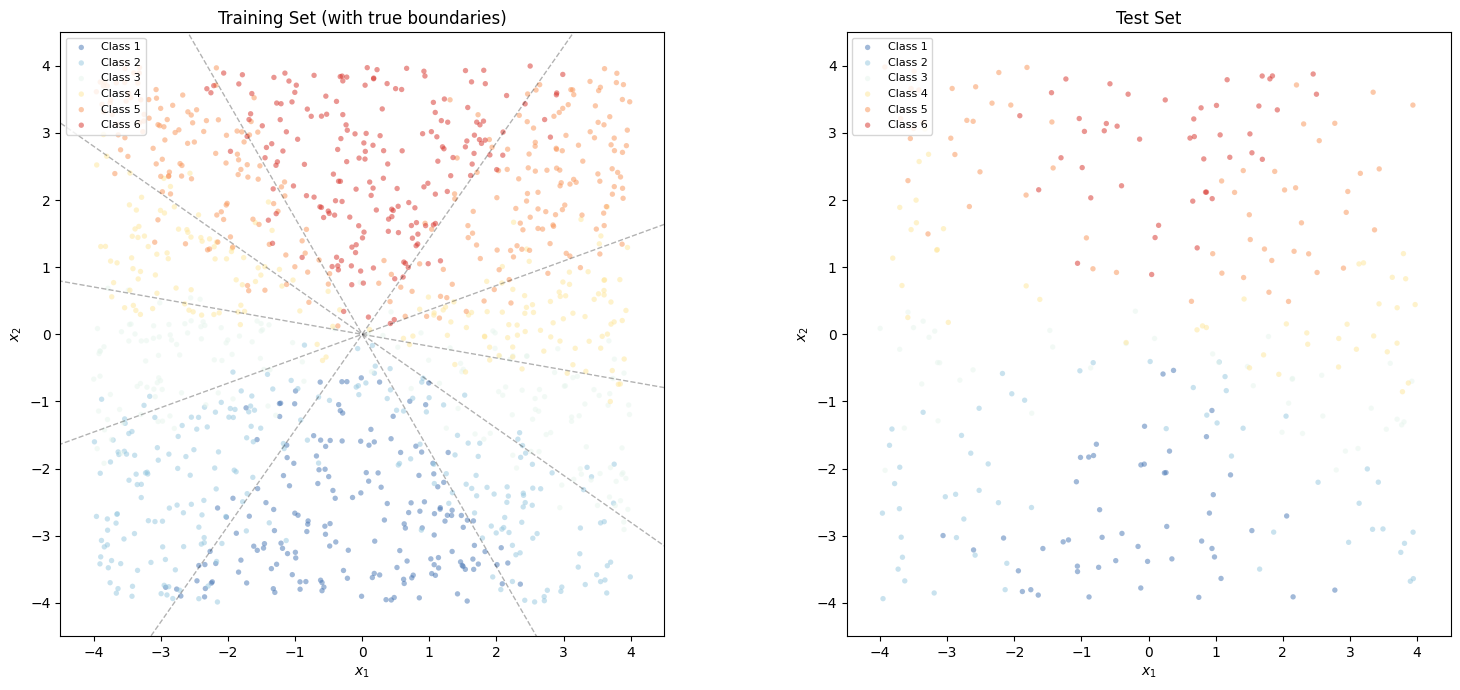

In [4]:
# Color scheme for 6 ordinal classes
CLASS_COLORS = plt.cm.RdYlBu_r(np.linspace(0.1, 0.9, K))

def plot_dataset(X, y, title="Dataset", ax=None, show_boundaries=True):
    """Plot 2D dataset colored by ordinal class."""
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(8, 8))
    
    for cls in range(1, K + 1):
        mask = y == cls
        ax.scatter(X[mask, 0], X[mask, 1], c=[CLASS_COLORS[cls - 1]], 
                   label=f"Class {cls}", alpha=0.5, s=15, edgecolors='none')
    
    if show_boundaries:
        # Draw true boundary lines
        for angle in true_angles:
            # Line perpendicular to normal: direction = (-sin(angle), cos(angle))
            dx, dy = -np.sin(angle), np.cos(angle)
            t = np.linspace(-6, 6, 100)
            ax.plot(dx * t, dy * t, 'k--', alpha=0.3, linewidth=1)
    
    ax.set_xlim(-4.5, 4.5)
    ax.set_ylim(-4.5, 4.5)
    ax.set_aspect('equal')
    ax.legend(loc='upper left', fontsize=8)
    ax.set_title(title)
    ax.set_xlabel("$x_1$")
    ax.set_ylabel("$x_2$")
    return ax

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
plot_dataset(X_train, y_train, "Training Set (with true boundaries)", axes[0])
plot_dataset(X_test, y_test, "Test Set", axes[1], show_boundaries=False)
plt.tight_layout()
plt.show()

---
## 3. Implementing the Loss Functions from Scratch

All implementations use raw PyTorch tensors with `requires_grad=True` — no `nn.Module` wrappers. Every mathematical operation is transparent.

In [5]:
# ============================================================
# 3a. CORAL Loss
# ============================================================
# Parameters: w (shared, [2]), b (independent biases, [K-1])
# Logit for threshold k: h_k(x) = w^T x + b_k
# Loss: binary CE summed over all N samples and K-1 thresholds

def coral_loss(X: torch.Tensor, y: torch.Tensor, w: torch.Tensor, b: torch.Tensor) -> torch.Tensor:
    """CORAL loss (Cao et al., 2019, Eq. 4).
    
    Args:
        X: [N, 2] features
        y: [N] class labels in {1, ..., K}
        w: [2] shared weight vector
        b: [K-1] independent biases
    Returns:
        Scalar loss
    """
    # Extended binary labels: y_tilde[i, k] = 1 if y_i > k+1
    y_tilde = encode_ordinal_labels(y, K)  # [N, K-1]
    
    # Logits: h_k(x_i) = w^T x_i + b_k    (broadcast over K-1 thresholds)
    # X @ w -> [N], unsqueeze to [N, 1], then + b [K-1] broadcasts to [N, K-1]
    logits = (X @ w).unsqueeze(1) + b.unsqueeze(0)  # [N, K-1]
    
    # Binary cross-entropy (numerically stable via logsigmoid)
    # -[y * log(sigma(h)) + (1-y) * log(1 - sigma(h))]
    # = -[y * log_sigmoid(h) + (1-y) * log_sigmoid(-h)]
    log_sig = torch.nn.functional.logsigmoid(logits)      # log(sigma(h))
    log_1_minus_sig = torch.nn.functional.logsigmoid(-logits)  # log(1 - sigma(h))
    
    bce = -(y_tilde * log_sig + (1 - y_tilde) * log_1_minus_sig)  # [N, K-1]
    
    return bce.mean()  # average over samples and thresholds


def coral_predict(X: torch.Tensor, w: torch.Tensor, b: torch.Tensor) -> torch.Tensor:
    """CORAL inference: predicted class = 1 + sum of thresholds exceeded."""
    logits = (X @ w).unsqueeze(1) + b.unsqueeze(0)  # [N, K-1]
    probs = torch.sigmoid(logits)    # P(y > k)
    return 1 + (probs > 0.5).sum(dim=1)  # [N], values in {1, ..., K}


print("CORAL: shared w ∈ R², independent b ∈ R^(K-1)")
print(f"  Total parameters: {2 + N_THRESHOLDS} = {2 + N_THRESHOLDS}")

CORAL: shared w ∈ R², independent b ∈ R^(K-1)
  Total parameters: 7 = 7


In [6]:
# ============================================================
# 3b. coGOL Loss (All-Thresholds with Generalized Coefficients)
# ============================================================
# Parameters: W (independent per threshold, [K-1, 2]), theta (biases, [K-1])
# Decision function for threshold j: g_tilde_j(x) = theta_j - w_j^T x
# phi(z) = log(1 + exp(-z))  (logistic surrogate)

def cogol_loss(
    X: torch.Tensor, y: torch.Tensor, 
    W: torch.Tensor, theta: torch.Tensor,
    alpha: float = 0.001, beta: float = 0.01,
) -> torch.Tensor:
    """coGOL all-thresholds loss (Lu et al., 2022, Eq. 3.3).
    
    Args:
        X: [N, 2] features
        y: [N] class labels in {1, ..., K}
        W: [K-1, 2] independent weight vectors per threshold
        theta: [K-1] bias terms
        alpha: L2 weight decay coefficient
        beta: deviation penalty coefficient (the key hyperparameter)
    Returns:
        Scalar loss
    """
    N = X.shape[0]
    
    # g_tilde_j(x_i) = theta_j - w_j^T x_i   for each threshold j
    # W: [K-1, 2], X: [N, 2] -> X @ W^T: [N, K-1]
    g_tilde = theta.unsqueeze(0) - X @ W.T  # [N, K-1]
    
    # Logistic surrogate: phi(z) = log(1 + exp(-z)) = softplus(-z) 
    # = -log_sigmoid(z)  (numerically stable)
    # phi(-z) = -log_sigmoid(-z)
    
    total_loss = torch.tensor(0.0)
    
    for i in range(N):
        yi = y[i].item()  # true class (1-indexed)
        
        # Sum over j=1..yi-1: phi(-g_tilde_j(x_i))
        # These are thresholds BELOW the true class -> we want g_j < 0 (class > j)
        for j in range(yi - 1):  # j = 0, 1, ..., yi-2 (0-indexed for K-1 thresholds)
            total_loss = total_loss - torch.nn.functional.logsigmoid(-g_tilde[i, j])
        
        # Sum over j=yi..K-1: phi(g_tilde_j(x_i))  
        # These are thresholds AT or ABOVE the true class -> we want g_j > 0 (class <= j)
        for j in range(yi - 1, N_THRESHOLDS):  # j = yi-1, ..., K-2 (0-indexed)
            total_loss = total_loss - torch.nn.functional.logsigmoid(g_tilde[i, j])
    
    total_loss = total_loss / N
    
    # L2 weight decay: alpha * sum ||w_j||^2
    l2_penalty = alpha * (W ** 2).sum()
    
    # Deviation penalty: beta * sum ||delta_j||^2 where delta_j = w_j - w_{j-1}
    deltas = W[1:] - W[:-1]  # [K-2, 2]
    deviation_penalty = beta * (deltas ** 2).sum()
    
    return total_loss + l2_penalty + deviation_penalty


# Vectorized version (much faster for training)
def cogol_loss_vectorized(
    X: torch.Tensor, y: torch.Tensor,
    W: torch.Tensor, theta: torch.Tensor,
    alpha: float = 0.001, beta: float = 0.01,
) -> torch.Tensor:
    """Vectorized coGOL loss — equivalent to loop version but fast."""
    N = X.shape[0]
    
    # g_tilde[i, j] = theta_j - w_j^T x_i
    g_tilde = theta.unsqueeze(0) - X @ W.T  # [N, K-1]
    
    # Build mask: for each sample i, thresholds j < y_i get phi(-g), thresholds j >= y_i get phi(g)
    # threshold indices: 0, 1, ..., K-2 correspond to thresholds 1, ..., K-1
    # y is 1-indexed, so threshold j (0-indexed) is "below" if j < y-1, "at or above" if j >= y-1
    threshold_idx = torch.arange(N_THRESHOLDS).unsqueeze(0)  # [1, K-1]
    y_shifted = (y - 1).unsqueeze(1)  # [N, 1], now 0-indexed class boundary
    
    below_mask = (threshold_idx < y_shifted).float()  # [N, K-1]: 1 for j < y-1
    above_mask = 1.0 - below_mask                     # [N, K-1]: 1 for j >= y-1
    
    # phi(-g) = -log_sigmoid(-g) for thresholds below true class
    # phi(g) = -log_sigmoid(g) for thresholds at or above true class
    loss_below = -torch.nn.functional.logsigmoid(-g_tilde) * below_mask
    loss_above = -torch.nn.functional.logsigmoid(g_tilde) * above_mask
    
    data_loss = (loss_below + loss_above).sum() / N
    
    # Regularization
    l2_penalty = alpha * (W ** 2).sum()
    deltas = W[1:] - W[:-1]
    deviation_penalty = beta * (deltas ** 2).sum()
    
    return data_loss + l2_penalty + deviation_penalty


def cogol_predict(X: torch.Tensor, W: torch.Tensor, theta: torch.Tensor) -> torch.Tensor:
    """coGOL inference: count thresholds where g_tilde < 0."""
    g_tilde = theta.unsqueeze(0) - X @ W.T  # [N, K-1]
    # g_tilde < 0 means the sample exceeds this threshold
    return 1 + (g_tilde < 0).sum(dim=1)  # [N]


print("coGOL: independent W ∈ R^(K-1 x 2), theta ∈ R^(K-1)")
print(f"  Total parameters: {N_THRESHOLDS * 2 + N_THRESHOLDS} = {N_THRESHOLDS * 3}")
print(f"  Hyperparameters: alpha (L2 decay), beta (deviation penalty)")

coGOL: independent W ∈ R^(K-1 x 2), theta ∈ R^(K-1)
  Total parameters: 15 = 15
  Hyperparameters: alpha (L2 decay), beta (deviation penalty)


In [7]:
# ============================================================
# 3c. Verify loop and vectorized coGOL give same result
# ============================================================
torch.manual_seed(0)
W_test = torch.randn(N_THRESHOLDS, 2, requires_grad=False)
theta_test = torch.randn(N_THRESHOLDS, requires_grad=False)

# Use a small subset for the slow loop version
X_small, y_small = X_train[:50], y_train[:50]

loss_loop = cogol_loss(X_small, y_small, W_test, theta_test, alpha=0.01, beta=0.05)
loss_vec = cogol_loss_vectorized(X_small, y_small, W_test, theta_test, alpha=0.01, beta=0.05)

print(f"Loop loss:       {loss_loop.item():.6f}")
print(f"Vectorized loss: {loss_vec.item():.6f}")
print(f"Match: {torch.allclose(loss_loop, loss_vec, atol=1e-5)}")

Loop loss:       9.891647
Vectorized loss: 9.891644
Match: True


In [8]:
# ============================================================
# 3d. MSE Baseline
# ============================================================
# Simple linear regression: predict continuous class value
# Parameters: w_mse (weights, [2]), b_mse (scalar bias)

def mse_loss(X: torch.Tensor, y: torch.Tensor, w: torch.Tensor, b: torch.Tensor) -> torch.Tensor:
    """MSE regression loss — treats ordinal classes as continuous values."""
    preds = X @ w + b  # [N]
    return ((preds - y.float()) ** 2).mean()

def mse_predict(X: torch.Tensor, w: torch.Tensor, b: torch.Tensor) -> torch.Tensor:
    """MSE inference: round prediction to nearest integer, clamp to [1, K]."""
    preds = X @ w + b
    return preds.round().clamp(1, K).long()

print("MSE: w ∈ R², b ∈ R (scalar)")
print(f"  Total parameters: 3")

MSE: w ∈ R², b ∈ R (scalar)
  Total parameters: 3


---
## 4. Training All Three Models

We train each model with Adam optimizer, logging loss and MAE at each epoch.

In [9]:
def compute_mae(y_true: torch.Tensor, y_pred: torch.Tensor) -> float:
    """Mean Absolute Error between ordinal predictions."""
    return (y_true.float() - y_pred.float()).abs().mean().item()

def compute_accuracy(y_true: torch.Tensor, y_pred: torch.Tensor) -> float:
    """Exact match accuracy."""
    return (y_true == y_pred).float().mean().item()

def count_rank_violations(probs: torch.Tensor) -> int:
    """Count samples where P(y>k) is not monotonically decreasing.
    probs: [N, K-1] predicted probabilities.
    """
    violations = 0
    for i in range(probs.shape[0]):
        for j in range(probs.shape[1] - 1):
            if probs[i, j] < probs[i, j + 1]:
                violations += 1
                break  # one violation per sample is enough
    return violations

In [10]:
# ============================================================
# 4a. Train CORAL
# ============================================================
N_EPOCHS = 500
LR = 0.05

torch.manual_seed(42)
w_coral = torch.randn(2, requires_grad=True)
b_coral = torch.zeros(N_THRESHOLDS, requires_grad=True)

optimizer_coral = torch.optim.Adam([w_coral, b_coral], lr=LR)
coral_history = {"train_loss": [], "test_mae": []}

for epoch in range(N_EPOCHS):
    optimizer_coral.zero_grad()
    loss = coral_loss(X_train, y_train, w_coral, b_coral)
    loss.backward()
    optimizer_coral.step()
    
    coral_history["train_loss"].append(loss.item())
    
    with torch.no_grad():
        preds = coral_predict(X_test, w_coral, b_coral)
        coral_history["test_mae"].append(compute_mae(y_test, preds))

print(f"CORAL — Final train loss: {coral_history['train_loss'][-1]:.4f}, "
      f"Test MAE: {coral_history['test_mae'][-1]:.4f}")
print(f"  Learned w: [{w_coral[0].item():.3f}, {w_coral[1].item():.3f}]")
print(f"  Learned b: {[f'{bi.item():.3f}' for bi in b_coral]}")

CORAL — Final train loss: 0.2193, Test MAE: 0.4433
  Learned w: [0.191, 1.733]
  Learned b: ['4.981', '2.091', '0.095', '-1.897', '-4.929']


In [11]:
# ============================================================
# 4b. Train coGOL
# ============================================================
torch.manual_seed(42)
W_cogol = torch.randn(N_THRESHOLDS, 2, requires_grad=True)
theta_cogol = torch.zeros(N_THRESHOLDS, requires_grad=True)

ALPHA = 0.001
BETA = 0.01

optimizer_cogol = torch.optim.Adam([W_cogol, theta_cogol], lr=LR)
cogol_history = {"train_loss": [], "test_mae": []}

for epoch in range(N_EPOCHS):
    optimizer_cogol.zero_grad()
    loss = cogol_loss_vectorized(X_train, y_train, W_cogol, theta_cogol, alpha=ALPHA, beta=BETA)
    loss.backward()
    optimizer_cogol.step()
    
    cogol_history["train_loss"].append(loss.item())
    
    with torch.no_grad():
        preds = cogol_predict(X_test, W_cogol, theta_cogol)
        cogol_history["test_mae"].append(compute_mae(y_test, preds))

print(f"coGOL — Final train loss: {cogol_history['train_loss'][-1]:.4f}, "
      f"Test MAE: {cogol_history['test_mae'][-1]:.4f}")
print(f"  alpha={ALPHA}, beta={BETA}")
print(f"  Learned W (each row is a threshold's weight vector):")
for j in range(N_THRESHOLDS):
    print(f"    w_{j+1}: [{W_cogol[j, 0].item():.3f}, {W_cogol[j, 1].item():.3f}]")

coGOL — Final train loss: 1.0280, Test MAE: 0.4667
  alpha=0.001, beta=0.01
  Learned W (each row is a threshold's weight vector):
    w_1: [0.015, 1.222]
    w_2: [0.301, 2.079]
    w_3: [0.368, 2.561]
    w_4: [0.287, 2.096]
    w_5: [0.100, 1.043]


In [12]:
# ============================================================
# 4c. Train MSE
# ============================================================
torch.manual_seed(42)
w_mse = torch.randn(2, requires_grad=True)
b_mse = torch.zeros(1, requires_grad=True)

optimizer_mse = torch.optim.Adam([w_mse, b_mse], lr=LR)
mse_history = {"train_loss": [], "test_mae": []}

for epoch in range(N_EPOCHS):
    optimizer_mse.zero_grad()
    loss = mse_loss(X_train, y_train, w_mse, b_mse)
    loss.backward()
    optimizer_mse.step()
    
    mse_history["train_loss"].append(loss.item())
    
    with torch.no_grad():
        preds = mse_predict(X_test, w_mse, b_mse)
        mse_history["test_mae"].append(compute_mae(y_test, preds))

print(f"MSE — Final train loss: {mse_history['train_loss'][-1]:.4f}, "
      f"Test MAE: {mse_history['test_mae'][-1]:.4f}")

MSE — Final train loss: 0.5121, Test MAE: 0.4633


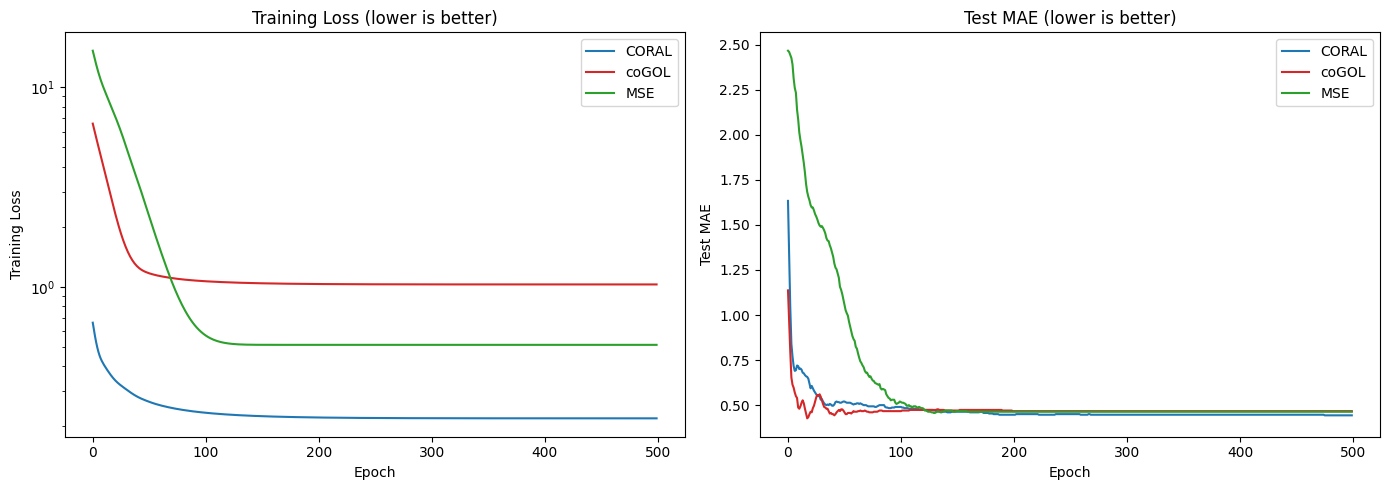

In [13]:
# ============================================================
# 4d. Training dynamics — loss and MAE curves
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curves
axes[0].plot(coral_history["train_loss"], label="CORAL", color="tab:blue")
axes[0].plot(cogol_history["train_loss"], label="coGOL", color="tab:red")
axes[0].plot(mse_history["train_loss"], label="MSE", color="tab:green")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Training Loss")
axes[0].set_title("Training Loss (lower is better)")
axes[0].legend()
axes[0].set_yscale("log")

# MAE curves
axes[1].plot(coral_history["test_mae"], label="CORAL", color="tab:blue")
axes[1].plot(cogol_history["test_mae"], label="coGOL", color="tab:red")
axes[1].plot(mse_history["test_mae"], label="MSE", color="tab:green")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Test MAE")
axes[1].set_title("Test MAE (lower is better)")
axes[1].legend()

plt.tight_layout()
plt.show()

---
## 5. Decision Boundary Visualization

This is the key visual. CORAL must produce **parallel** lines (same slope). coGOL can produce lines with **different slopes**, capturing the fanning structure of the data.

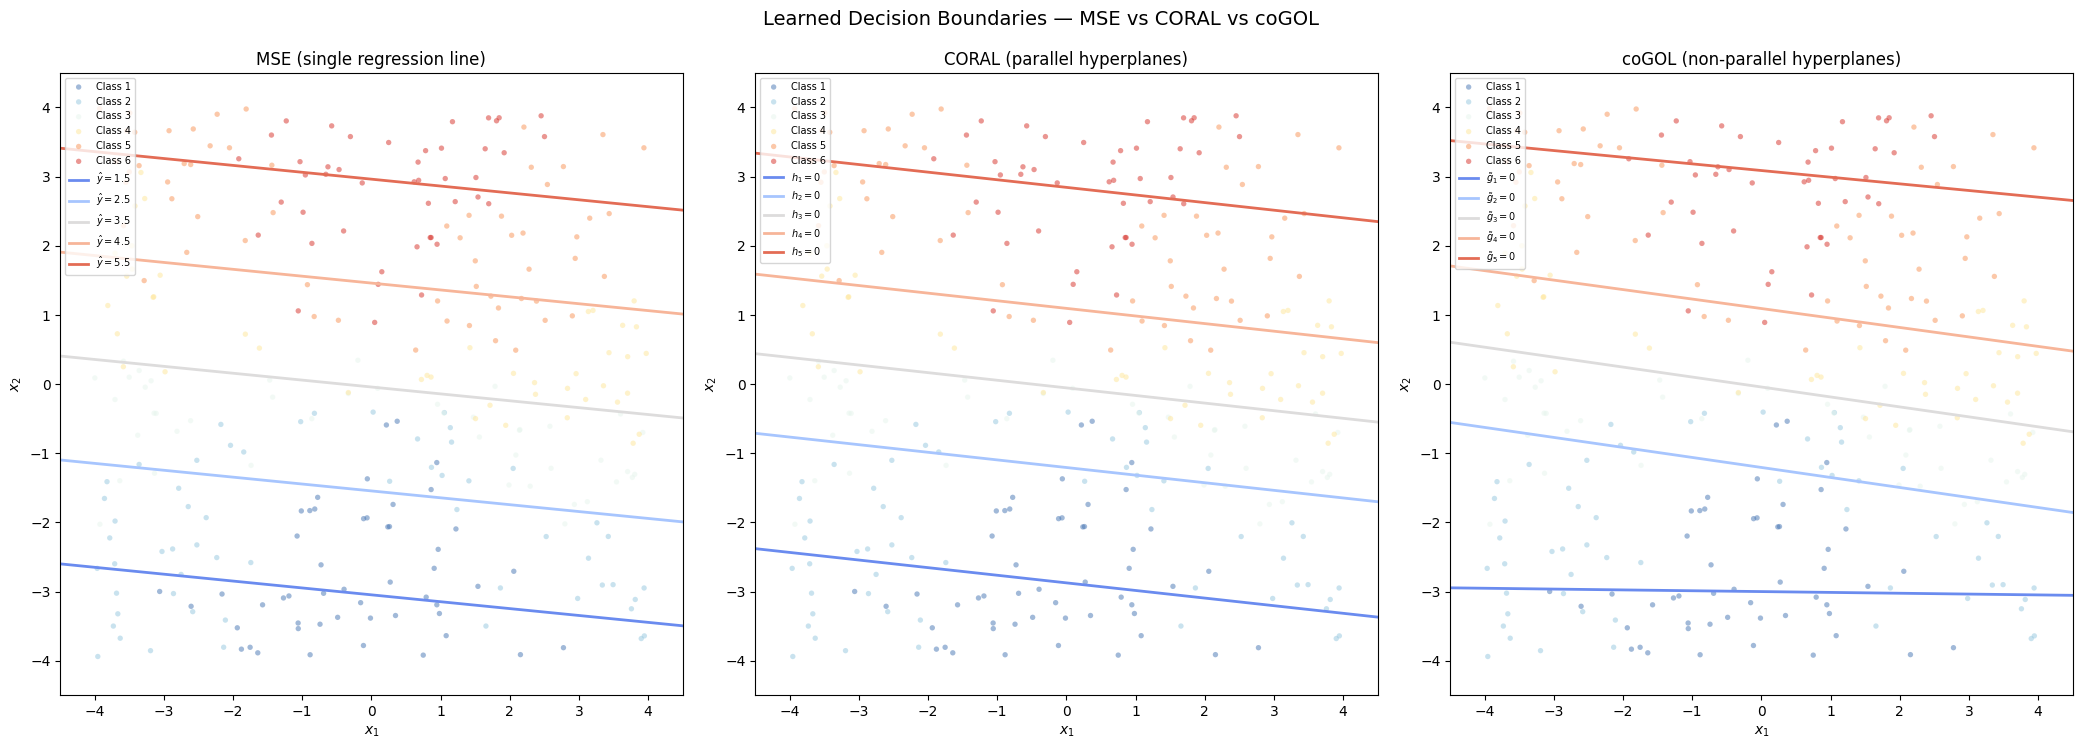

In [14]:
def plot_coral_boundaries(ax, w, b, X, y):
    """Plot CORAL decision boundaries: w^T x + b_k = 0  ->  x2 = -(w1*x1 + b_k) / w2"""
    plot_dataset(X, y, "CORAL (parallel hyperplanes)", ax, show_boundaries=False)
    
    x1_range = np.linspace(-4.5, 4.5, 200)
    colors = plt.cm.coolwarm(np.linspace(0.15, 0.85, N_THRESHOLDS))
    
    w_np = w.detach().numpy()
    b_np = b.detach().numpy()
    
    for k in range(N_THRESHOLDS):
        if abs(w_np[1]) > 1e-6:
            x2_boundary = -(w_np[0] * x1_range + b_np[k]) / w_np[1]
            mask = (x2_boundary > -4.5) & (x2_boundary < 4.5)
            ax.plot(x1_range[mask], x2_boundary[mask], '-', color=colors[k], 
                    linewidth=2, label=f"$h_{k+1}=0$")
    ax.legend(fontsize=7, loc='upper left')


def plot_cogol_boundaries(ax, W, theta, X, y):
    """Plot coGOL decision boundaries: theta_j - w_j^T x = 0  ->  x2 = (theta_j - w_j1*x1) / w_j2"""
    plot_dataset(X, y, "coGOL (non-parallel hyperplanes)", ax, show_boundaries=False)
    
    x1_range = np.linspace(-4.5, 4.5, 200)
    colors = plt.cm.coolwarm(np.linspace(0.15, 0.85, N_THRESHOLDS))
    
    W_np = W.detach().numpy()
    theta_np = theta.detach().numpy()
    
    for j in range(N_THRESHOLDS):
        if abs(W_np[j, 1]) > 1e-6:
            x2_boundary = (theta_np[j] - W_np[j, 0] * x1_range) / W_np[j, 1]
            mask = (x2_boundary > -4.5) & (x2_boundary < 4.5)
            ax.plot(x1_range[mask], x2_boundary[mask], '-', color=colors[j],
                    linewidth=2, label=f"$\\tilde{{g}}_{j+1}=0$")
    ax.legend(fontsize=7, loc='upper left')


def plot_mse_boundary(ax, w, b, X, y):
    """Plot MSE iso-prediction lines for each integer class."""
    plot_dataset(X, y, "MSE (single regression line)", ax, show_boundaries=False)
    
    x1_range = np.linspace(-4.5, 4.5, 200)
    colors = plt.cm.coolwarm(np.linspace(0.15, 0.85, N_THRESHOLDS))
    
    w_np = w.detach().numpy()
    b_np = b.detach().numpy()
    
    # Decision boundaries at y_hat = 1.5, 2.5, ..., 5.5
    for k, threshold in enumerate([1.5, 2.5, 3.5, 4.5, 5.5]):
        if abs(w_np[1]) > 1e-6:
            x2_boundary = (threshold - b_np[0] - w_np[0] * x1_range) / w_np[1]
            mask = (x2_boundary > -4.5) & (x2_boundary < 4.5)
            ax.plot(x1_range[mask], x2_boundary[mask], '-', color=colors[k],
                    linewidth=2, label=f"$\\hat{{y}}={threshold}$")
    ax.legend(fontsize=7, loc='upper left')


# Main comparison plot
fig, axes = plt.subplots(1, 3, figsize=(21, 7))

plot_mse_boundary(axes[0], w_mse, b_mse, X_test, y_test)
plot_coral_boundaries(axes[1], w_coral, b_coral, X_test, y_test)
plot_cogol_boundaries(axes[2], W_cogol, theta_cogol, X_test, y_test)

plt.suptitle("Learned Decision Boundaries — MSE vs CORAL vs coGOL", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
## 6. Predicted Probability Heatmaps

For CORAL and coGOL, we can visualize the predicted $\hat{P}(y > k)$ for each threshold $k$ as a heatmap over the 2D space. CORAL's probabilities are **guaranteed monotonic** by the weight-sharing constraint. coGOL's may occasionally violate monotonicity, but the deviation penalty keeps them well-behaved.

/var/folders/96/z3c724y12xn_vlpnrx8w6lgw0000gn/T/ipykernel_78829/4132491687.py:34: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


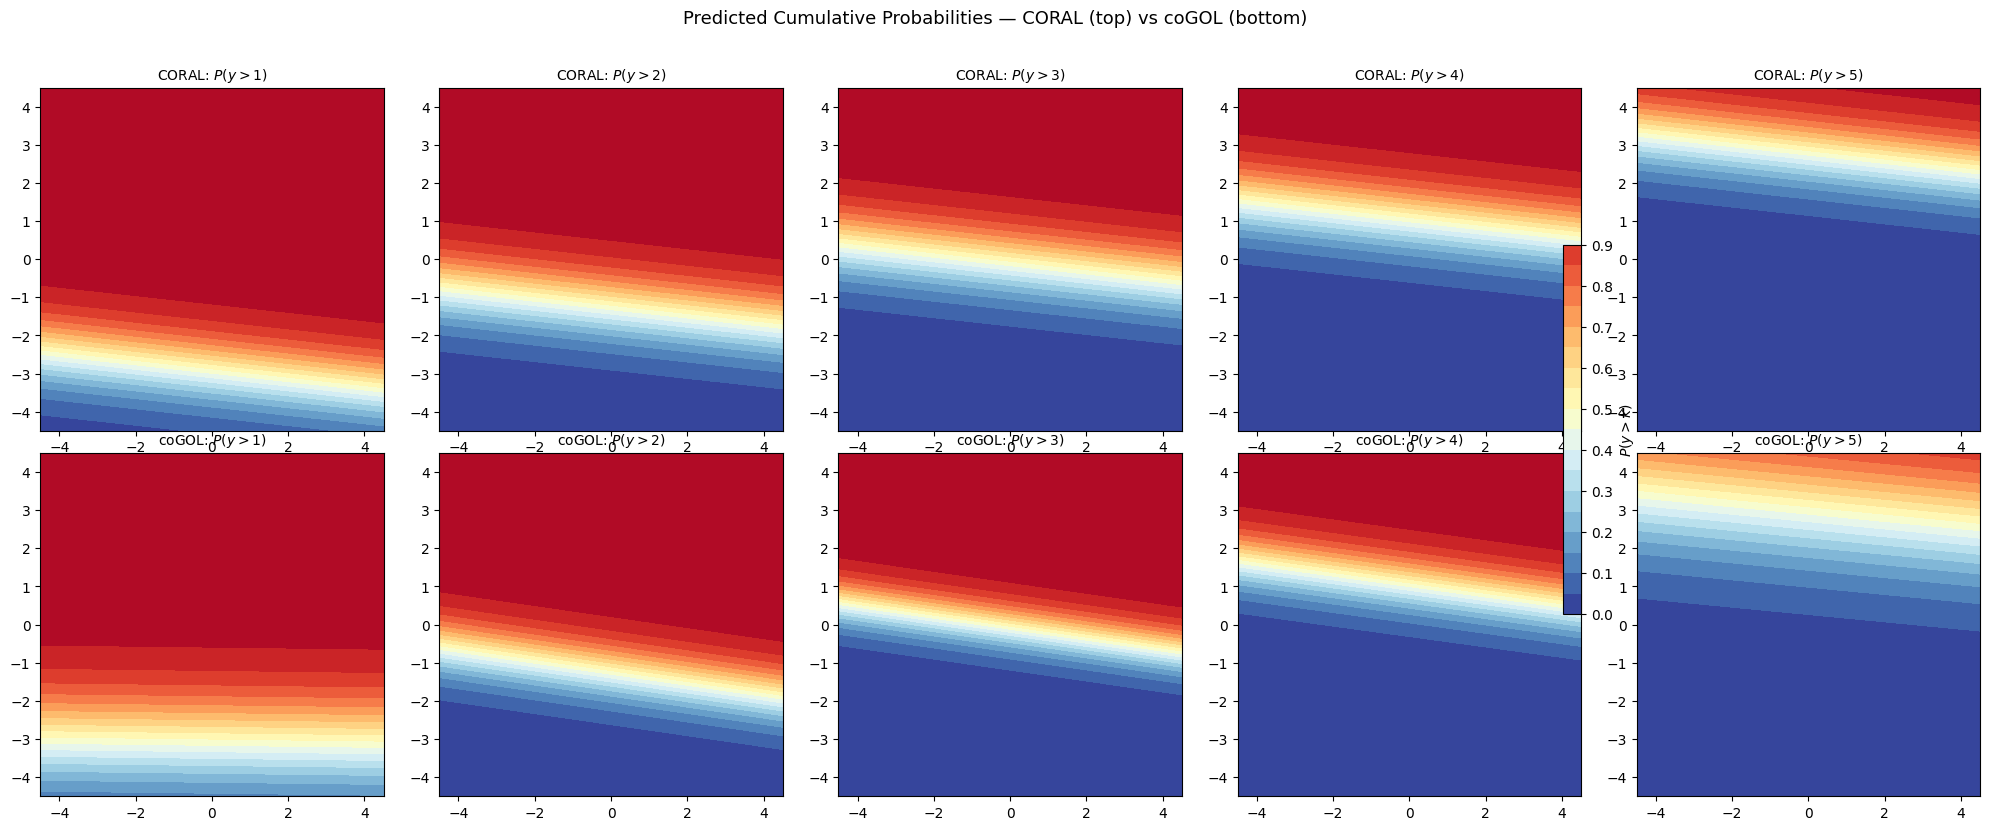

In [15]:
# Create a grid of 2D points for probability heatmaps
grid_res = 150
x1_grid = np.linspace(-4.5, 4.5, grid_res)
x2_grid = np.linspace(-4.5, 4.5, grid_res)
xx1, xx2 = np.meshgrid(x1_grid, x2_grid)
X_grid = torch.tensor(np.column_stack([xx1.ravel(), xx2.ravel()]), dtype=torch.float32)

with torch.no_grad():
    # CORAL probabilities: P(y > k) = sigma(w^T x + b_k)
    coral_probs = torch.sigmoid((X_grid @ w_coral).unsqueeze(1) + b_coral.unsqueeze(0))  # [N_grid, K-1]
    
    # coGOL probabilities: P(y > j) = sigma(-g_tilde_j(x)) = sigma(w_j^T x - theta_j)
    g_tilde_grid = theta_cogol.unsqueeze(0) - X_grid @ W_cogol.T  # [N_grid, K-1]
    cogol_probs = torch.sigmoid(-g_tilde_grid)  # [N_grid, K-1]

# Plot P(y > k) for each threshold k
fig, axes = plt.subplots(2, N_THRESHOLDS, figsize=(20, 8))

for k in range(N_THRESHOLDS):
    # CORAL
    prob_map = coral_probs[:, k].numpy().reshape(grid_res, grid_res)
    im = axes[0, k].contourf(xx1, xx2, prob_map, levels=20, cmap='RdYlBu_r', vmin=0, vmax=1)
    axes[0, k].set_title(f"CORAL: $P(y > {k+1})$", fontsize=10)
    axes[0, k].set_aspect('equal')
    
    # coGOL
    prob_map = cogol_probs[:, k].numpy().reshape(grid_res, grid_res)
    im = axes[1, k].contourf(xx1, xx2, prob_map, levels=20, cmap='RdYlBu_r', vmin=0, vmax=1)
    axes[1, k].set_title(f"coGOL: $P(y > {k+1})$", fontsize=10)
    axes[1, k].set_aspect('equal')

fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.6, label="$P(y > k)$")
plt.suptitle("Predicted Cumulative Probabilities — CORAL (top) vs coGOL (bottom)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# Rank consistency check
# ============================================================
with torch.no_grad():
    # CORAL on test set
    coral_test_probs = torch.sigmoid((X_test @ w_coral).unsqueeze(1) + b_coral.unsqueeze(0))
    coral_violations = count_rank_violations(coral_test_probs)
    
    # coGOL on test set  
    g_tilde_test = theta_cogol.unsqueeze(0) - X_test @ W_cogol.T
    cogol_test_probs = torch.sigmoid(-g_tilde_test)
    cogol_violations = count_rank_violations(cogol_test_probs)

print("=== Rank Consistency Check ===")
print(f"CORAL: {coral_violations}/{len(X_test)} samples with non-monotonic P(y>k)")
print(f"       → {coral_violations} violations (should be 0 — guaranteed by weight sharing)")
print(f"coGOL: {cogol_violations}/{len(X_test)} samples with non-monotonic P(y>k)")
print(f"       → {cogol_violations} violations (not guaranteed, but β regularization helps)")

---
## 7. Effect of $\beta$ — The Key Hyperparameter

$\beta$ controls the **deviation penalty** in coGOL. It interpolates between:
- $\beta = 0$ → **GOL/OR-CNN**: fully independent hyperplanes (maximum flexibility, risk of overfitting)
- $\beta \to \infty$ → **CORAL**: forced parallel hyperplanes (maximum inductive bias, risk of underfitting)
- $0 < \beta < \infty$ → **coGOL**: smooth interpolation (neighboring hyperplanes are encouraged to be similar)

We train coGOL for several values of $\beta$ and plot the decision boundaries + MAE.

In [16]:
# ============================================================
# 7a. Train coGOL for different beta values
# ============================================================
beta_values = [0.0, 0.001, 0.01, 0.05, 0.1, 0.5, 1.0, 10.0, 100.0]
beta_results = {}

for beta_val in beta_values:
    torch.manual_seed(42)
    W_b = torch.randn(N_THRESHOLDS, 2, requires_grad=True)
    theta_b = torch.zeros(N_THRESHOLDS, requires_grad=True)
    opt = torch.optim.Adam([W_b, theta_b], lr=LR)
    
    for epoch in range(N_EPOCHS):
        opt.zero_grad()
        loss = cogol_loss_vectorized(X_train, y_train, W_b, theta_b, alpha=ALPHA, beta=beta_val)
        loss.backward()
        opt.step()
    
    with torch.no_grad():
        preds = cogol_predict(X_test, W_b, theta_b)
        mae = compute_mae(y_test, preds)
        acc = compute_accuracy(y_test, preds)
        
        g_tilde_test = theta_b.unsqueeze(0) - X_test @ W_b.T
        test_probs = torch.sigmoid(-g_tilde_test)
        violations = count_rank_violations(test_probs)
    
    beta_results[beta_val] = {
        "W": W_b.detach().clone(),
        "theta": theta_b.detach().clone(),
        "mae": mae,
        "acc": acc,
        "violations": violations,
    }
    print(f"β={beta_val:>7.3f} → MAE={mae:.4f}, Acc={acc:.4f}, Rank violations={violations}")

print(f"\nFor reference — CORAL MAE: {coral_history['test_mae'][-1]:.4f}")

β=  0.000 → MAE=0.4800, Acc=0.5367, Rank violations=280
β=  0.001 → MAE=0.4767, Acc=0.5400, Rank violations=273
β=  0.010 → MAE=0.4667, Acc=0.5500, Rank violations=214
β=  0.050 → MAE=0.4433, Acc=0.5733, Rank violations=12
β=  0.100 → MAE=0.4433, Acc=0.5733, Rank violations=0
β=  0.500 → MAE=0.4467, Acc=0.5700, Rank violations=0
β=  1.000 → MAE=0.4467, Acc=0.5700, Rank violations=0
β= 10.000 → MAE=0.4300, Acc=0.5867, Rank violations=0
β=100.000 → MAE=0.8733, Acc=0.2467, Rank violations=0

For reference — CORAL MAE: 0.4433


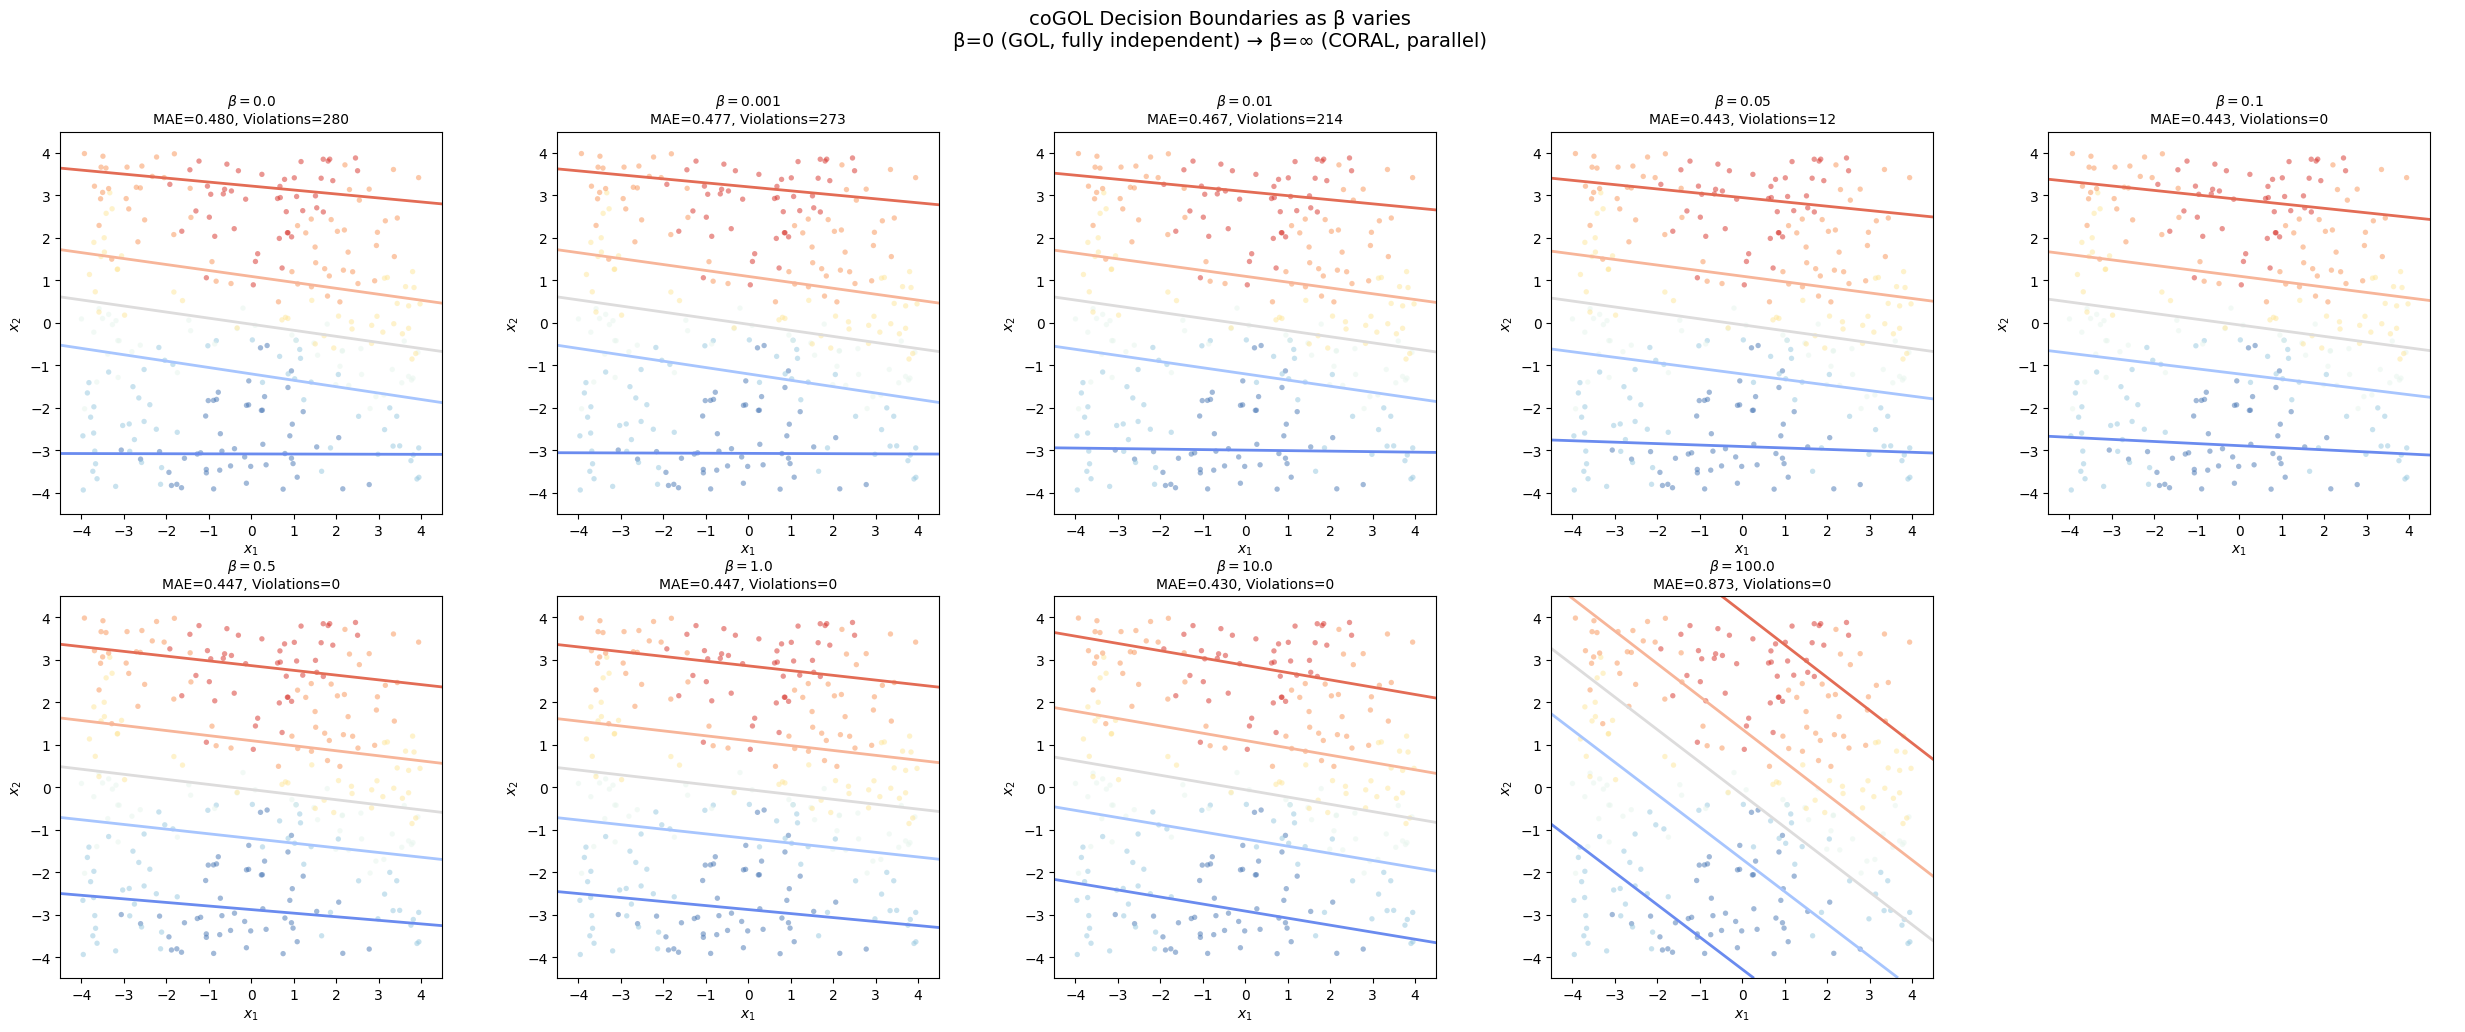

In [17]:
# ============================================================
# 7b. Decision boundaries for each beta value
# ============================================================
n_betas = len(beta_values)
fig, axes = plt.subplots(2, 5, figsize=(25, 10))
axes = axes.flatten()

for idx, beta_val in enumerate(beta_values):
    ax = axes[idx]
    res = beta_results[beta_val]
    plot_cogol_boundaries(ax, res["W"], res["theta"], X_test, y_test)
    ax.set_title(f"$\\beta={beta_val}$\nMAE={res['mae']:.3f}, Violations={res['violations']}", fontsize=10)
    ax.legend().remove()

# Hide the extra subplot
if n_betas < len(axes):
    axes[-1].axis('off')

plt.suptitle("coGOL Decision Boundaries as β varies\n"
             "β=0 (GOL, fully independent) → β=∞ (CORAL, parallel)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

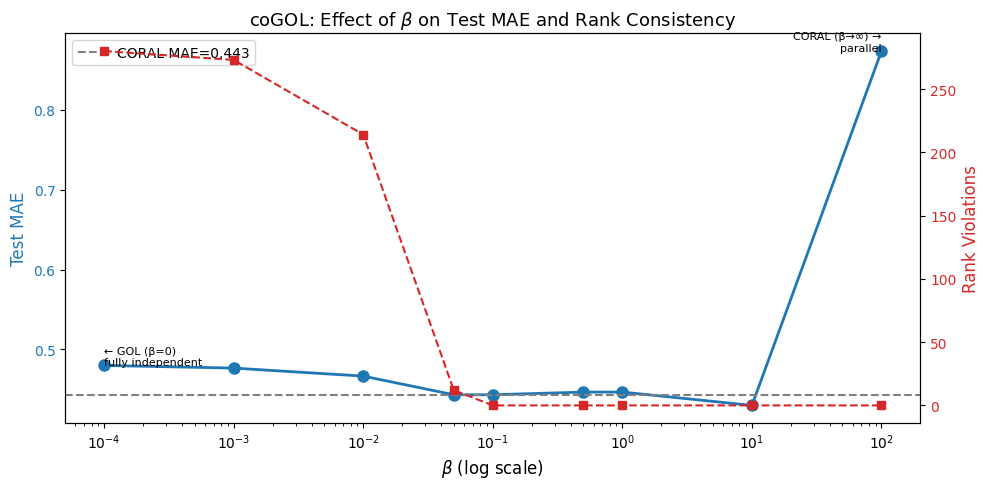

In [18]:
# ============================================================
# 7c. MAE vs beta curve
# ============================================================
fig, ax1 = plt.subplots(figsize=(10, 5))

betas = list(beta_results.keys())
maes = [beta_results[b]["mae"] for b in betas]
violations = [beta_results[b]["violations"] for b in betas]

# Replace 0 with a small value for log scale
betas_plot = [max(b, 1e-4) for b in betas]

color1 = 'tab:blue'
ax1.semilogx(betas_plot, maes, 'o-', color=color1, linewidth=2, markersize=8)
ax1.axhline(y=coral_history["test_mae"][-1], color='gray', linestyle='--', label=f"CORAL MAE={coral_history['test_mae'][-1]:.3f}")
ax1.set_xlabel("$\\beta$ (log scale)", fontsize=12)
ax1.set_ylabel("Test MAE", color=color1, fontsize=12)
ax1.tick_params(axis='y', labelcolor=color1)

# Second y-axis for rank violations
color2 = 'tab:red'
ax2 = ax1.twinx()
ax2.semilogx(betas_plot, violations, 's--', color=color2, linewidth=1.5, markersize=6)
ax2.set_ylabel("Rank Violations", color=color2, fontsize=12)
ax2.tick_params(axis='y', labelcolor=color2)

ax1.legend(fontsize=10)
ax1.set_title("coGOL: Effect of $\\beta$ on Test MAE and Rank Consistency", fontsize=13)

# Annotate
ax1.annotate("← GOL (β=0)\nfully independent", xy=(1e-4, maes[0]), fontsize=8, ha='left')
ax1.annotate("CORAL (β→∞) →\nparallel", xy=(100, maes[-1]), fontsize=8, ha='right')

plt.tight_layout()
plt.show()

---
## 8. Adding a Nonlinear Backbone (Small ResNet)

### Why the linear models struggle

The fanning dataset assigns classes by **counting** how many boundary normals have positive dot product. The threshold "is $y > k$?" becomes "are more than $k$ normals positive?" — and that region is an **angular sector** (wedge-shaped), not a half-plane.

A linear model (one line per threshold) can only approximate these wedges. The best-fit lines for each threshold end up with **similar orientations**, which is why the slopes don't fan out.

### The fix: shared nonlinear backbone + ordinal heads

This mirrors the real project architecture (ESM backbone → heads):

```
x ∈ R²  →  ResNet(x) → h ∈ R^d  →  ordinal head(h) → logits
```

- **Deep CORAL**: backbone warps features so boundaries are curved in input space, but still **parallel in feature space** (shared $\mathbf{w}$)
- **Deep coGOL**: boundaries are curved AND **non-parallel** — can capture the fanning wedges

In [ ]:
# ============================================================
# 8a. Small ResNet backbone + Deep CORAL / Deep coGOL
# ============================================================
import torch.nn as nn
import torch.nn.functional as F

class ResBlock(nn.Module):
    """Pre-activation residual block: BN -> ReLU -> Linear -> BN -> ReLU -> Linear + skip."""
    def __init__(self, dim: int) -> None:
        super().__init__()
        self.bn1 = nn.BatchNorm1d(dim)
        self.fc1 = nn.Linear(dim, dim)
        self.bn2 = nn.BatchNorm1d(dim)
        self.fc2 = nn.Linear(dim, dim)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        residual = x
        out = torch.relu(self.bn1(x))
        out = self.fc1(out)
        out = torch.relu(self.bn2(out))
        out = self.fc2(out)
        return out + residual


class ResNetBackbone(nn.Module):
    """Tiny ResNet: project -> N residual blocks -> features."""
    def __init__(self, input_dim: int = 2, hidden_dim: int = 32, n_blocks: int = 3) -> None:
        super().__init__()
        self.proj = nn.Linear(input_dim, hidden_dim)
        self.blocks = nn.Sequential(*[ResBlock(hidden_dim) for _ in range(n_blocks)])
        self.out_dim = hidden_dim

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        h = torch.relu(self.proj(x))
        return self.blocks(h)


class DeepCORAL(nn.Module):
    """ResNet backbone + shared w + independent biases (parallel in feature space)."""
    def __init__(self, input_dim: int = 2, hidden_dim: int = 32,
                 n_blocks: int = 3, n_thresholds: int = N_THRESHOLDS) -> None:
        super().__init__()
        self.backbone = ResNetBackbone(input_dim, hidden_dim, n_blocks)
        self.shared_fc = nn.Linear(hidden_dim, 1, bias=False)
        self.biases = nn.Parameter(torch.zeros(n_thresholds))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        h = self.backbone(x)
        logits = self.shared_fc(h) + self.biases  # [N, n_thresholds]
        return logits

    @torch.no_grad()
    def predict(self, x: torch.Tensor) -> torch.Tensor:
        self.eval()
        logits = self.forward(x)
        self.train()
        return 1 + (torch.sigmoid(logits) > 0.5).sum(dim=1)


class DeepCoGOL(nn.Module):
    """ResNet backbone + per-threshold w_j + deviation penalty (non-parallel in feature space)."""
    def __init__(self, input_dim: int = 2, hidden_dim: int = 32,
                 n_blocks: int = 3, n_thresholds: int = N_THRESHOLDS) -> None:
        super().__init__()
        self.backbone = ResNetBackbone(input_dim, hidden_dim, n_blocks)
        self.W = nn.Linear(hidden_dim, n_thresholds, bias=False)
        self.theta = nn.Parameter(torch.zeros(n_thresholds))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        h = self.backbone(x)
        g_tilde = self.theta.unsqueeze(0) - self.W(h)  # [N, n_thresholds]
        return g_tilde

    @torch.no_grad()
    def predict(self, x: torch.Tensor) -> torch.Tensor:
        self.eval()
        g_tilde = self.forward(x)
        self.train()
        return 1 + (g_tilde < 0).sum(dim=1)

    def deviation_penalty(self) -> torch.Tensor:
        W = self.W.weight  # [n_thresholds, hidden_dim]
        deltas = W[1:] - W[:-1]
        return (deltas ** 2).sum()

    def l2_head_penalty(self) -> torch.Tensor:
        return (self.W.weight ** 2).sum()


print(f"ResNet backbone: 2 -> 32 (proj) -> 3 ResBlocks (32-dim) -> 32-dim features")
print(f"Deep CORAL params: {sum(p.numel() for p in DeepCORAL().parameters()):,}")
print(f"Deep coGOL params: {sum(p.numel() for p in DeepCoGOL().parameters()):,}")

In [ ]:
# ============================================================
# 8b. Train Deep CORAL
# ============================================================
DEEP_EPOCHS = 1000
DEEP_LR = 0.005

torch.manual_seed(42)
deep_coral = DeepCORAL()
optimizer_dc = torch.optim.Adam(deep_coral.parameters(), lr=DEEP_LR)
deep_coral_history = {"train_loss": [], "test_mae": []}

for epoch in range(DEEP_EPOCHS):
    deep_coral.train()
    optimizer_dc.zero_grad()
    logits = deep_coral(X_train)
    y_tilde = encode_ordinal_labels(y_train, K)
    loss = F.binary_cross_entropy_with_logits(logits, y_tilde)
    loss.backward()
    optimizer_dc.step()

    deep_coral_history["train_loss"].append(loss.item())
    with torch.no_grad():
        preds = deep_coral.predict(X_test)
        deep_coral_history["test_mae"].append(compute_mae(y_test, preds))

    if (epoch + 1) % 200 == 0:
        print(f"  Epoch {epoch+1}/{DEEP_EPOCHS} -- loss: {loss.item():.4f}, "
              f"test MAE: {deep_coral_history['test_mae'][-1]:.4f}")

print(f"\nDeep CORAL -- Final test MAE: {deep_coral_history['test_mae'][-1]:.4f}"
      f" (linear CORAL was {coral_history['test_mae'][-1]:.4f})")

In [ ]:
# ============================================================
# 8c. Train Deep coGOL
# ============================================================
DEEP_ALPHA = 0.0001
DEEP_BETA = 0.01

torch.manual_seed(42)
deep_cogol = DeepCoGOL()
optimizer_dcg = torch.optim.Adam(deep_cogol.parameters(), lr=DEEP_LR)
deep_cogol_history = {"train_loss": [], "test_mae": []}

for epoch in range(DEEP_EPOCHS):
    deep_cogol.train()
    optimizer_dcg.zero_grad()
    g_tilde = deep_cogol(X_train)  # [N, K-1]

    # All-thresholds loss (vectorized)
    threshold_idx = torch.arange(N_THRESHOLDS).unsqueeze(0)
    y_shifted = (y_train - 1).unsqueeze(1)
    below_mask = (threshold_idx < y_shifted).float()
    above_mask = 1.0 - below_mask

    loss_below = -F.logsigmoid(-g_tilde) * below_mask
    loss_above = -F.logsigmoid(g_tilde) * above_mask
    data_loss = (loss_below + loss_above).sum() / X_train.shape[0]

    loss = (data_loss
            + DEEP_ALPHA * deep_cogol.l2_head_penalty()
            + DEEP_BETA * deep_cogol.deviation_penalty())
    loss.backward()
    optimizer_dcg.step()

    deep_cogol_history["train_loss"].append(loss.item())
    with torch.no_grad():
        preds = deep_cogol.predict(X_test)
        deep_cogol_history["test_mae"].append(compute_mae(y_test, preds))

    if (epoch + 1) % 200 == 0:
        print(f"  Epoch {epoch+1}/{DEEP_EPOCHS} -- loss: {loss.item():.4f}, "
              f"test MAE: {deep_cogol_history['test_mae'][-1]:.4f}")

print(f"\nDeep coGOL -- Final test MAE: {deep_cogol_history['test_mae'][-1]:.4f}"
      f" (linear coGOL was {cogol_history['test_mae'][-1]:.4f})")

In [ ]:
# ============================================================
# 8d. Decision boundary visualization -- Deep models
# ============================================================
def plot_class_contours(ax, predict_fn, X, y, title):
    """Plot predicted class regions as filled contours + scatter data."""
    with torch.no_grad():
        grid_preds = predict_fn(X_grid).float().numpy().reshape(grid_res, grid_res)

    levels = np.arange(0.5, K + 1.5, 1)
    ax.contourf(xx1, xx2, grid_preds, levels=levels, colors=CLASS_COLORS, alpha=0.35)
    ax.contour(xx1, xx2, grid_preds, levels=levels, colors='k', linewidths=1.5, alpha=0.6)

    for cls in range(1, K + 1):
        mask = y == cls
        ax.scatter(X[mask, 0], X[mask, 1], c=[CLASS_COLORS[cls - 1]],
                   alpha=0.5, s=12, edgecolors='none')

    for angle in true_angles:
        dx, dy = -np.sin(angle), np.cos(angle)
        t = np.linspace(-6, 6, 100)
        ax.plot(dx * t, dy * t, 'k--', alpha=0.2, linewidth=1)

    ax.set_xlim(-4.5, 4.5)
    ax.set_ylim(-4.5, 4.5)
    ax.set_aspect('equal')
    ax.set_title(title, fontsize=11)


fig, axes = plt.subplots(1, 4, figsize=(28, 7))

# Linear CoGOL (best beta)
best_beta = min(beta_results, key=lambda b: beta_results[b]["mae"])
best_W = beta_results[best_beta]["W"]
best_theta = beta_results[best_beta]["theta"]
plot_class_contours(axes[0],
    lambda x: cogol_predict(x, best_W, best_theta),
    X_test, y_test,
    f"Linear coGOL (best)\nMAE={beta_results[best_beta]['mae']:.3f}")

# Linear CORAL
plot_class_contours(axes[1],
    lambda x: coral_predict(x, w_coral, b_coral),
    X_test, y_test,
    f"Linear CORAL\nMAE={coral_history['test_mae'][-1]:.3f}")

# Deep CORAL
plot_class_contours(axes[2],
    deep_coral.predict,
    X_test, y_test,
    f"Deep CORAL (ResNet)\nMAE={deep_coral_history['test_mae'][-1]:.3f}")

# Deep coGOL
plot_class_contours(axes[3],
    deep_cogol.predict,
    X_test, y_test,
    f"Deep coGOL (ResNet)\nMAE={deep_cogol_history['test_mae'][-1]:.3f}")

plt.suptitle("Linear vs Deep: The backbone lets the loss function shine\n"
             "Dashed lines = true fanning boundaries", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# 8e. Training curves -- deep models
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(deep_coral_history["train_loss"], label="Deep CORAL", color="tab:blue")
axes[0].plot(deep_cogol_history["train_loss"], label="Deep coGOL", color="tab:red")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Training Loss")
axes[0].set_title("Deep Models -- Training Loss")
axes[0].legend()
axes[0].set_yscale("log")

axes[1].plot(deep_coral_history["test_mae"], label="Deep CORAL", color="tab:blue")
axes[1].plot(deep_cogol_history["test_mae"], label="Deep coGOL", color="tab:red")
axes[1].axhline(y=coral_history["test_mae"][-1], color="tab:blue",
                linestyle="--", alpha=0.4, label=f"Linear CORAL ({coral_history['test_mae'][-1]:.3f})")
axes[1].axhline(y=cogol_history["test_mae"][-1], color="tab:red",
                linestyle="--", alpha=0.4, label=f"Linear coGOL ({cogol_history['test_mae'][-1]:.3f})")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Test MAE")
axes[1].set_title("Deep Models -- Test MAE (dashed = linear baselines)")
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# 8f. Full comparison table -- all 5 models
# ============================================================
with torch.no_grad():
    deep_coral.eval()
    deep_cogol.eval()

    dc_preds = deep_coral.predict(X_test)
    dc_mae = compute_mae(y_test, dc_preds)
    dc_acc = compute_accuracy(y_test, dc_preds)
    dc_logits = deep_coral(X_test)
    dc_probs = torch.sigmoid(dc_logits)
    dc_viol = count_rank_violations(dc_probs)

    dcg_preds = deep_cogol.predict(X_test)
    dcg_mae = compute_mae(y_test, dcg_preds)
    dcg_acc = compute_accuracy(y_test, dcg_preds)
    dcg_g = deep_cogol(X_test)
    dcg_probs = torch.sigmoid(-dcg_g)
    dcg_viol = count_rank_violations(dcg_probs)

    coral_test_probs = torch.sigmoid((X_test @ w_coral).unsqueeze(1) + b_coral.unsqueeze(0))
    lin_coral_viol = count_rank_violations(coral_test_probs)

dc_params = sum(p.numel() for p in deep_coral.parameters())
dcg_params = sum(p.numel() for p in deep_cogol.parameters())

best_beta = min(beta_results, key=lambda b: beta_results[b]["mae"])
best_res = beta_results[best_beta]

print("=" * 80)
print(f"{'Model':<25} {'MAE':>8} {'Accuracy':>10} {'Rank Viol.':>12} {'Params':>10}")
print("=" * 80)
print(f"{'MSE (linear)':<25} {mse_mae:>8.4f} {mse_acc:>10.4f} {'N/A':>12} {3:>10}")
print(f"{'CORAL (linear)':<25} {coral_mae:>8.4f} {coral_acc:>10.4f} {lin_coral_viol:>12} {2+N_THRESHOLDS:>10}")
cogol_line = f"coGOL (linear)"
print(f"{cogol_line:<25} {best_res['mae']:>8.4f} {best_res['acc']:>10.4f} {best_res['violations']:>12} {N_THRESHOLDS*3:>10}")
print("-" * 80)
print(f"{'Deep CORAL (ResNet)':<25} {dc_mae:>8.4f} {dc_acc:>10.4f} {dc_viol:>12} {dc_params:>10,}")
print(f"{'Deep coGOL (ResNet)':<25} {dcg_mae:>8.4f} {dcg_acc:>10.4f} {dcg_viol:>12} {dcg_params:>10,}")
print("=" * 80)

---
## 9. Summary

### Final Comparison Table

In [19]:
# ============================================================
# Final evaluation on test set
# ============================================================
with torch.no_grad():
    # MSE
    mse_preds = mse_predict(X_test, w_mse, b_mse)
    mse_mae = compute_mae(y_test, mse_preds)
    mse_acc = compute_accuracy(y_test, mse_preds)
    
    # CORAL
    coral_preds = coral_predict(X_test, w_coral, b_coral)
    coral_mae = compute_mae(y_test, coral_preds)
    coral_acc = compute_accuracy(y_test, coral_preds)
    
    # coGOL (best beta from sweep)
    best_beta = min(beta_results, key=lambda b: beta_results[b]["mae"])
    best_res = beta_results[best_beta]
    cogol_preds = cogol_predict(X_test, best_res["W"], best_res["theta"])
    cogol_mae = best_res["mae"]
    cogol_acc = best_res["acc"]
    cogol_viol = best_res["violations"]

print("=" * 70)
print(f"{'Model':<20} {'MAE':>8} {'Accuracy':>10} {'Rank Violations':>16} {'Parameters':>12}")
print("=" * 70)
print(f"{'MSE':<20} {mse_mae:>8.4f} {mse_acc:>10.4f} {'N/A':>16} {3:>12}")
print(f"{'CORAL':<20} {coral_mae:>8.4f} {coral_acc:>10.4f} {coral_violations:>16} {2 + N_THRESHOLDS:>12}")
print(f"{'coGOL (β=' + f'{best_beta})':<20} {cogol_mae:>8.4f} {cogol_acc:>10.4f} {cogol_viol:>16} {N_THRESHOLDS * 3:>12}")
print("=" * 70)
print(f"\nBest β for coGOL: {best_beta}")

Model                     MAE   Accuracy  Rank Violations   Parameters
MSE                    0.4633     0.5667              N/A            3


NameError: name 'coral_violations' is not defined

### Key Takeaways

1. **Linear models can't capture this dataset.** The fanning dataset assigns classes by counting boundary crossings, creating **wedge-shaped** threshold regions. A single line per threshold can only approximate these wedges, which is why linear coGOL's slopes don't fan out.

2. **The backbone is what unlocks the loss function.** A small ResNet warps the 2D input into a feature space where the wedge-shaped boundaries become linearly separable. This mirrors the real project: ESM embeddings are the nonlinear features, and the ordinal head operates on top.

3. **Deep CORAL vs Deep coGOL**: Both benefit from the backbone, but Deep coGOL can capture more structure because its per-threshold weights learn **different directions in feature space**. CORAL's shared weight forces all thresholds to be parallel even in the learned feature space.

4. **CORAL guarantees rank consistency** (zero violations) via shared weights. coGOL trades strict rank consistency for flexibility, with $\beta$ controlling the tradeoff.

5. **The $\beta$ hyperparameter** interpolates between GOL ($\beta=0$, fully independent) and CORAL ($\beta \to \infty$, parallel). It should be tuned via Optuna alongside other hyperparameters.

### Implications for the Novozymes Project

- The ESM backbone plays the role of the ResNet here — it provides the nonlinear feature extraction
- Whether CORAL or coGOL wins depends on whether stability boundaries in ESM space are approximately parallel
- $\beta$ is a tunable hyperparameter (Optuna) — not something to guess
- The existing CORAL and coGOL implementations in `src/novozymes/training/losses/` need to match these paper-faithful formulations (all-thresholds loss, deviation penalty)